In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

- Class = 0 : 사기가 아니다 , = 1 : 사기다
- Amount : 사용액

In [2]:
# 1. 데이터 로딩

card_df = pd.read_csv('./creditcard.csv')
print(card_df.shape)
card_df.head(3)

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [3]:
card_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
card_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# Time 제거하는 함수
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    df_copy.drop('Time',axis=1,inplace=True)
    return df_copy

In [6]:
# 학습/테스트 분리
from sklearn.model_selection import train_test_split

def get_train_test_dataset(df=None): #df : 원본 데이터프레임
    df_copy = get_preprocessed_df(df) # Time feature drop한 것
    # 데이터와 레이블 분리
    X_features = df_copy.iloc[:,:-1]
    y_target = df_copy.iloc[:,-1]
    # 학습/ 테스트 분리
    X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_target,
    test_size= 0.3,
    random_state = 0,
    stratify=y_target # 불균형 데이터일 때 반드시 처리 필요
    )
    return X_train, X_test, y_train, y_test

In [7]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

In [8]:
# 학습/테스트 데이터 레이블 분포 확인
print('학습 데이터 레이블 값 비율')
# print(y_train.value_counts())
# print(y_train.shape)
print(y_train.value_counts() / y_train.shape[0] * 100)
print('테스트 데이터 레이블 값 비율')
# print(y_test.value_counts())
# print(y_test.shape)
print(y_test.value_counts() / y_test.shape[0] * 100)

학습 데이터 레이블 값 비율
Class
0    99.827451
1     0.172549
Name: count, dtype: float64
테스트 데이터 레이블 값 비율
Class
0    99.826785
1     0.173215
Name: count, dtype: float64


In [9]:
# 평가 함수
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

def get_clf_eval(y_test, pred, pred_proba):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)
    roc_auc = roc_auc_score(y_test,pred_proba)
    print('오차 행렬')
    print(confusion)
    print(f'정확도 : {accuracy:.4f}, 정밀도 : {precision:.4f}, 재현율 : {recall:.4f},\
        F1 : {f1:.4f}, ROC_AUC : {roc_auc:.4f}')

In [10]:
# 1. 이진 분류 : LogisticRegression
from sklearn.linear_model import LogisticRegression

# 1. object 생성
lr_clf = LogisticRegression(max_iter = 1000)
# 2. 학습
lr_clf.fit(X_train, y_train)

# 3. 예측값, 예측확률
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:,1]

# 4. 평가
get_clf_eval(y_test, lr_pred, lr_pred_proba)

오차 행렬
[[85280    15]
 [   56    92]]
정확도 : 0.9992, 정밀도 : 0.8598, 재현율 : 0.6216,        F1 : 0.7216, ROC_AUC : 0.9735


In [11]:
# def objective_func(search_space,model):
    # model_clf = model() => 모델 바꿔치기하면서 하면 함수를 추가로 만들지 않아도 됨
def get_model_train_eval(model, ftr_train, ftr_test, tgt_train, tgt_test):
                 # 재료(lr_clf, X_train, X_test, y_train, y_test)
    model.fit(ftr_train,tgt_train)
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:,1]
    get_clf_eval(tgt_test,pred,pred_proba)

In [38]:
# LightGBM
from lightgbm import LGBMClassifier
lgbm_clf = LGBMClassifier(
    n_estimators = 1000,
    num_leaves=64,
    n_jobs=-1, # 병렬처리 하겠다는 뜻
    boost_from_average = False,
    verbosity = -1
)
get_model_train_eval(
    lgbm_clf,
    ftr_train = X_train,
    ftr_test = X_test,
    tgt_train = y_train,
    tgt_test = y_test
)

오차 행렬
[[85290     5]
 [   25   121]]
정확도 : 0.9996, 정밀도 : 0.9603, 재현율 : 0.8288,        F1 : 0.8897, ROC_AUC : 0.9780


In [45]:
from xgboost import XGBClassifier
xgb_clf = XGBClassifier(
    n_estimators = 1000
)

In [46]:
# get_model_train_eval(xgb_clf,X_train,X_test,y_train,y_test)

##### 왜도 / 첨도
- 왜도(skew) : 데이터의 비대칭성을 확인 => 비대칭일때는 로그변환 필요  

- 첨도(kurtosis) : 중앙 부분이 뾰족
    - 양의 첨도 : 꼬리가 두껍고 중앙 부분이 뾰족, 극단값이 자주 발생
        - 해결 : 극단값 처리 필요, 적절한 모델 선택 필요
    - 음의 첨도 : 꼬리가 얇고, 중앙 부분이 평평, 극단값 적게 발생
    - 중감 첨도(0에 가까운 경우) : 정규 분포를 따른다고 볼 수 있다.  
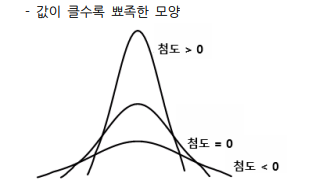  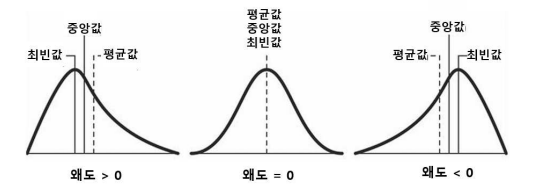

- 정규 분포: 왜도는 0에 가깝다, 첨도도 0에 가까운 경우를 이야기한다.

In [47]:
import seaborn as sns
from scipy.stats import skew, kurtosis
print(skew(card_df['Amount']))
# 왜도 16.97763503663313 
print(kurtosis(card_df['Amount']))
# 첨도 845.0777883188744 => 뾰족

16.97763503663313
845.0777883188744


### StandardScaler
- 크기를 조절할 뿐 정규분포로 바뀌는것이 아니다.

In [48]:
from sklearn.preprocessing import StandardScaler
# 기존 데이터(Amount), 평균, 표준 편차, 왜도, 첨도
avg_amount = card_df['Amount'].mean()
std_amount = card_df['Amount'].std()
print(avg_amount)                   # 88.34961925093134
print(std_amount)                   # 250.12010924018855
print(skew(card_df['Amount']))      # 16.97763503663313
print(kurtosis(card_df['Amount']))  # 845.0777883188744

88.34961925093134
250.12010924018855
16.97763503663313
845.0777883188744


In [49]:
# Scaling
# 정규분포로 변환한다 X -> 표준과 표준편차가 다른 feature들과 비슷해졌다
scaler = StandardScaler()
n_amount =  scaler.fit_transform(card_df['Amount'].values.reshape(-1,1))
print(f'정규화 후 평균 : {n_amount.mean()}')
print(f'정규화 후 표준편차 : {n_amount.std()}')
print(f'정규화 후 왜도 : {skew(n_amount)}')
print(f'정규화 후 첨도 : {kurtosis(n_amount)}')

정규화 후 평균 : -3.6723778103728753e-17
정규화 후 표준편차 : 1.0
정규화 후 왜도 : [16.97763504]
정규화 후 첨도 : [845.07778832]


In [50]:
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    scaler = StandardScaler()
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1,1))
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    
    df_copy.drop(['Time','Amount'],axis=1, inplace=True)
    return df_copy

In [51]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf,ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
# boost_from_average=False 빼먹으면 재현율 망함
get_model_train_eval(lgbm_clf,ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)



오차 행렬
[[85281    14]
 [   55    93]]
정확도 : 0.9992, 정밀도 : 0.8692, 재현율 : 0.6284,        F1 : 0.7294, ROC_AUC : 0.9706
오차 행렬
[[85290     5]
 [   37   111]]
정확도 : 0.9995, 정밀도 : 0.9569, 재현율 : 0.7500,        F1 : 0.8409, ROC_AUC : 0.9779


정확도 : 0.9992, 정밀도 : 0.8598, 재현율 : 0.6216, F1 : 0.7216, ROC_AUC : 0.9735 - Logistic  
정확도 : 0.9995, 정밀도 : 0.9483, 재현율 : 0.7432, F1 : 0.8333, ROC_AUC : 0.9717 - LGBM  
##### 결론 
※ Logistic은 조금 증가가 되었고 lGBM은 큰 차이가 없다



- log1p = 1p -> 1plus
    - x 는 0~1사이이면 안된다
    - x = 0일 때 -무한대가 일어나 plus 1을 해주는 것
    - 무한대가 나오면 연산이 다 망가지기 때문

In [52]:
# 로그 변환 추가
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'],axis=1, inplace=True)
    return df_copy

In [53]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf,ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
# boost_from_average=False 빼먹으면 재현율 망함
get_model_train_eval(lgbm_clf,ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)



오차 행렬
[[85282    13]
 [   59    89]]
정확도 : 0.9992, 정밀도 : 0.8725, 재현율 : 0.6014,        F1 : 0.7120, ROC_AUC : 0.9734
오차 행렬
[[85290     5]
 [   35   113]]
정확도 : 0.9995, 정밀도 : 0.9576, 재현율 : 0.7635,        F1 : 0.8496, ROC_AUC : 0.9796


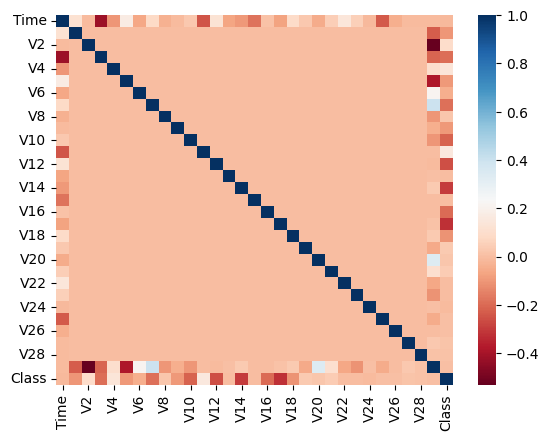

In [54]:
# 이상치 제거
import seaborn as sns

corr = card_df.corr()
sns.heatmap(corr, cmap='RdBu')
plt.show()

In [55]:
corr['Class'].sort_values(ascending=True)[:10]

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64

#### 이상치 검출 방식
- IQR :
- Z-score :
- DBSCAN :
- Isolation Forest(대용랑 고차원) :

In [56]:
fraud = card_df[card_df['Class']==1]['V14']
# print(fraud)
q_25 = np.percentile(fraud.values,25)
# print(q_25)
q_75 = np.percentile(fraud.values,75)
# print(q_75)
iqr = q_75 - q_25
print(iqr)
iqr_weight = iqr*1.5
lowest_val = q_25-iqr_weight
highest_val = q_75+iqr_weight
print(lowest_val, highest_val)

5.409902115485521
-17.807576138200666 3.8320323237414167


In [57]:
# 이상치 검출 방식 : IQR, Z-score, DBSCAN, Isolation Forest(대용랑,고차원) 다 해보기
# IQR
def get_outlier(df=None, column=None, weight=1.5): # 존 튜키
    fraud = df[df['Class']==1][column] # column = V14 , 피처 중 사기인 경우(=1)의 이상치 검출
    # 25%, 75%의 위치에 있는 값을 구한다.
    q_25 = np.percentile(fraud.values,25)
    q_75 = np.percentile(fraud.values,75)
    iqr = q_75 - q_25
    iqr_weight = iqr * weight
    lowest_val = q_25 - iqr_weight
    highest_val = q_75 + iqr_weight
    outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index
    return outlier_index
    

In [58]:
outlier_index = get_outlier(df=card_df,column='V14')
print(outlier_index)
card_df.iloc[outlier_index,:]['V14']

Index([8296, 8615, 9035, 9252], dtype='int64')


8296   -19.214325
8615   -18.822087
9035   -18.493773
9252   -18.049998
Name: V14, dtype: float64

In [59]:
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    # 로그변환
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0,'Amount Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    # 이상치 제거
    outlier_index = get_outlier(df_copy, 'V14')
    df_copy.drop(outlier_index, axis=0, inplace=True)
    return df_copy

In [60]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('### 로지스틱 회귀 예측 성능')
get_model_train_eval(lr_clf, X_train,X_test,y_train,y_test)
print('### LightGBM 에측 성능 ###')
get_model_train_eval(lgbm_clf, X_train,X_test,y_train,y_test)

### 로지스틱 회귀 예측 성능
오차 행렬
[[85280    15]
 [   48    98]]
정확도 : 0.9993, 정밀도 : 0.8673, 재현율 : 0.6712,        F1 : 0.7568, ROC_AUC : 0.9725
### LightGBM 에측 성능 ###
오차 행렬
[[85290     5]
 [   25   121]]
정확도 : 0.9996, 정밀도 : 0.9603, 재현율 : 0.8288,        F1 : 0.8897, ROC_AUC : 0.9780


In [29]:
# 오차 행렬
# [[85282    13]
#  [   59    89]]
# 정확도 : 0.9992, 정밀도 : 0.8725, 재현율 : 0.6014,        F1 : 0.7120, ROC_AUC : 0.9734
# 오차 행렬
# [[85290     5]
#  [   35   113]]
# 정확도 : 0.9995, 정밀도 : 0.9576, 재현율 : 0.7635,        F1 : 0.8496, ROC_AUC : 0.9796

In [61]:
# 오버 샘플링
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)

X_train_over, y_train_over = smote.fit_resample(X_train,y_train)
print(X_train.shape, y_train.shape)
print(X_train_over.shape, y_train_over.shape)

(199362, 29) (199362,)
(398040, 29) (398040,)


In [62]:
print(y_train.value_counts())
print(y_train_over.value_counts())

Class
0    199020
1       342
Name: count, dtype: int64
Class
0    199020
1    199020
Name: count, dtype: int64


In [63]:
get_model_train_eval(lr_clf,X_train_over,X_test,y_train_over,y_test) # Logistic
# 정확도 : 0.9993, 정밀도 : 0.8673, 재현율 : 0.6712,        F1 : 0.7568, ROC_AUC : 0.9725

오차 행렬
[[82933  2362]
 [   11   135]]
정확도 : 0.9722, 정밀도 : 0.0541, 재현율 : 0.9247,        F1 : 0.1022, ROC_AUC : 0.9736


In [64]:
get_model_train_eval(lgbm_clf,X_train_over, X_test, y_train_over, y_test) # LightGBM -> tree계열에서 이점이 있었다.
# 정확도 : 0.9996, 정밀도 : 0.9603, 재현율 : 0.8288,        F1 : 0.8897, ROC_AUC : 0.9780

오차 행렬
[[85283    12]
 [   22   124]]
정확도 : 0.9996, 정밀도 : 0.9118, 재현율 : 0.8493,        F1 : 0.8794, ROC_AUC : 0.9814


In [34]:
get_model_train_eval(xgb_clf,X_train_over, X_test, y_train_over, y_test)

오차 행렬
[[85267    28]
 [   21   125]]
정확도 : 0.9994, 정밀도 : 0.8170, 재현율 : 0.8562,        F1 : 0.8361, ROC_AUC : 0.9856


In [35]:
# 스태킹 앙상블 생각해보기

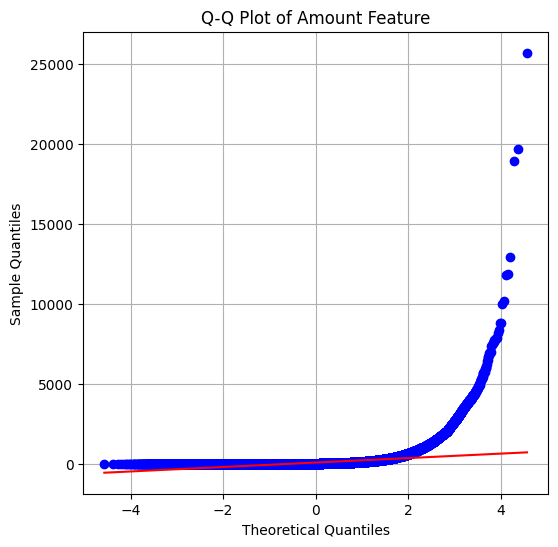

In [65]:
# q-qplot 돌려보기 (skew, kurtosis)
import matplotlib.pyplot as plt
import scipy.stats as stats


# Q-Q plot 그리기
plt.figure(figsize=(6, 6))
stats.probplot(card_df['Amount'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Amount Feature')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True)
plt.show()